In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import joblib

In [26]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 2000

data = pd.DataFrame({
    "income": np.random.normal(60000, 15000, n),
    "age": np.random.randint(21, 65, n),
    "employment_years": np.random.randint(0, 40, n),
    "loan_amount": np.random.normal(20000, 8000, n),
    "loan_term": np.random.choice([12,24,36,48,60], n),
    "credit_history_length": np.random.randint(0, 20, n),
    "num_credit_lines": np.random.randint(1, 10, n),
    "num_delinquencies": np.random.randint(0, 5, n),
    "debt_to_income_ratio": np.random.uniform(0.1, 0.6, n),
    "savings_balance": np.random.normal(15000, 7000, n),
})

# rule tạo label
data["approved"] = (
    (data["income"] > 50000) &
    (data["debt_to_income_ratio"] < 0.4) &
    (data["num_delinquencies"] < 2) &
    (data["employment_years"] > 2) &
    (data["credit_history_length"] > 3) &
    (data["loan_amount"] < data["income"] * 0.6) &
    (data["savings_balance"] > 5000)
).astype(int)

# thêm noise 5% để dataset realistic hơn
noise = np.random.rand(len(data)) < 0.05
data.loc[noise, "approved"] = 1 - data.loc[noise, "approved"]

data.head()

,income,age,employment_years,loan_amount,loan_term,credit_history_length,num_credit_lines,num_delinquencies,debt_to_income_ratio,savings_balance,approved
0,67450.712295,50,34,30141.212090,12,13,6,2,0.376134,19619.160194,0
1,57926.035482,51,20,22309.824024,60,3,7,4,0.456181,22391.236108,0
2,69715.328072,58,30,10743.067050,60,9,4,4,0.342269,1870.884005,0
3,82845.447846,31,18,9334.973162,36,2,7,0,0.212284,22772.366029,0
4,56487.699379,55,30,7587.902008,36,6,3,2,0.368639,19615.284727,0


In [27]:
missing_values = data.isnull().sum()
print(f"\n❌ Missing Values:")
print(missing_values[missing_values > 0])
print(f"\n✅ Không có missing values!"
      if missing_values.sum() == 0
      else "⚠️ Có missing values cần xử lý"
    )


❌ Missing Values:
Series([], dtype: int64)

✅ Không có missing values!


1.3 PHÂN PHỐI BIẾN TARGET

Số lượng mỗi class:
approved
0    1672
1     328
Name: count, dtype: int64

Tỷ lệ mỗi class:
approved
0    0.836
1    0.164
Name: proportion, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_2784\693204849.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='approved', data=data, palette='Set2')


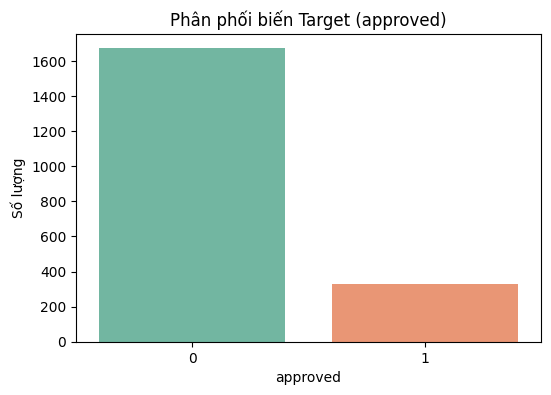

In [28]:
print("="*60)
print("1.3 PHÂN PHỐI BIẾN TARGET")
print("="*60)

print("\nSố lượng mỗi class:")
print(data['approved'].value_counts())

print("\nTỷ lệ mỗi class:")
print(data['approved'].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(x='approved', data=data, palette='Set2')
plt.title('Phân phối biến Target (approved)')
plt.xlabel('approved')
plt.ylabel('Số lượng')
plt.show()

Train/Test Split

In [29]:
X = data.drop("approved", axis=1)
y = data["approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train XGBoost

In [30]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [31]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       338
           1       0.87      0.74      0.80        62

    accuracy                           0.94       400
   macro avg       0.91      0.86      0.88       400
weighted avg       0.94      0.94      0.94       400



In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.92
ROC AUC: 0.8765985875167016
Confusion Matrix:
[[321  17]
 [ 15  47]]


Feature Importance

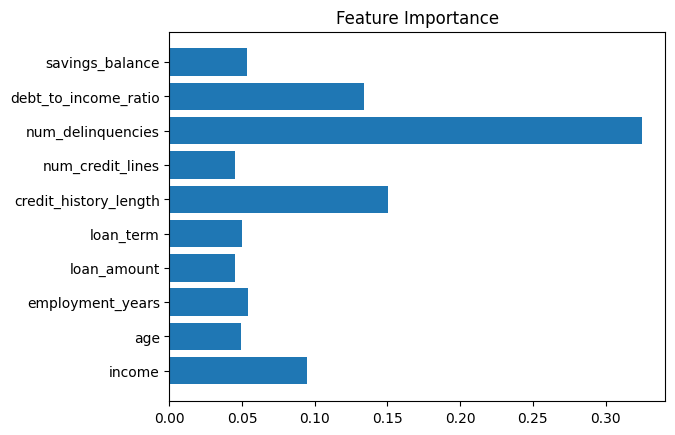

In [35]:
importances = model.feature_importances_
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

Export Model

In [11]:
joblib.dump(model, "credit_model.pkl")

['credit_model.pkl']

In [36]:
import joblib
model = joblib.load("../model/credit_model.pkl")
print("LOADED")

LOADED
